# Performance Analytics — Day 4
**Daily Returns | CAGR | Sharpe | Sortino | Alpha/Beta | Max Drawdown | Fund Scorecard | Benchmark Comparison**

In [1]:

import os
os.chdir(r'C:\Users\shagun\OneDrive\Desktop\cp_project')
import pandas as pd, numpy as np, matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings; warnings.filterwarnings('ignore')

fm   = pd.read_csv('data/raw/01_fund_master.csv')
nav  = pd.read_csv('data/raw/02_nav_history.csv', parse_dates=['date'])
bm   = pd.read_csv('data/raw/10_benchmark_indices.csv', parse_dates=['date'])

nav  = nav.sort_values(['amfi_code','date'])
RF   = 0.065 / 252  # RBI repo rate proxy daily

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
n100 = bm[bm['index_name']=='NIFTY100'].set_index('date')['close_value'].pct_change().dropna()
n50  = bm[bm['index_name']=='NIFTY50'].set_index('date')['close_value'].pct_change().dropna()

print("All data loaded ✓")
print("Daily return distribution:")
print(nav['daily_return'].describe().round(6))


All data loaded ✓
Daily return distribution:
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


## Task 1 — Daily Returns Validation

In [2]:

fig, axes = plt.subplots(1,2,figsize=(14,4))
sample = nav[nav['amfi_code']==119551]['daily_return'].dropna()
axes[0].hist(sample, bins=60, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[0].set_title("Daily Return Distribution — SBI Bluechip"); axes[0].set_xlabel("Daily Return"); axes[0].set_ylabel("Frequency")
axes[0].axvline(sample.mean(), color='red', linestyle='--', label=f'Mean={sample.mean():.4f}')
axes[0].legend()
all_rets = nav['daily_return'].dropna()
axes[1].hist(all_rets, bins=80, color='#10B981', edgecolor='white', alpha=0.8)
axes[1].set_title("Daily Return Distribution — All 40 Funds"); axes[1].set_xlabel("Daily Return")
plt.tight_layout(); plt.savefig('reports/chart_daily_returns.png', dpi=150); plt.show()
print(f"Max single-day gain : {all_rets.max():.2%}")
print(f"Max single-day loss : {all_rets.min():.2%}")
print(f"% positive days     : {(all_rets>0).mean():.1%}")


Max single-day gain : 6.47%
Max single-day loss : -5.81%
% positive days     : 54.5%


## Task 2 — CAGR Comparison Table

In [3]:

def cagr(nav_series, years):
    end_date = nav_series.index.max()
    s = nav_series[nav_series.index >= end_date - pd.DateOffset(years=years)].dropna()
    if len(s)<10: return np.nan
    return ((s.iloc[-1]/s.iloc[0])**(1/years)-1)*100

cagr_rows = []
for code, grp in nav.groupby('amfi_code'):
    ns   = grp.sort_values('date').set_index('date')['nav']
    name = fm.loc[fm['amfi_code']==code,'scheme_name'].values[0]
    cat  = fm.loc[fm['amfi_code']==code,'category'].values[0]
    cagr_rows.append({'scheme_name':name,'category':cat,
                      'CAGR_1yr':round(cagr(ns,1),2),
                      'CAGR_3yr':round(cagr(ns,3),2),
                      'CAGR_5yr':round(cagr(ns,5),2)})

cagr_df = pd.DataFrame(cagr_rows).sort_values('CAGR_3yr', ascending=False)
print(cagr_df.to_string(index=False))


                                          scheme_name category  CAGR_1yr  CAGR_3yr  CAGR_5yr
                  Axis Midcap Fund - Regular - Growth   Equity     22.26     35.11     24.45
        Mirae Asset Large Cap Fund - Regular - Growth   Equity     20.36     34.00     26.80
            ICICI Pru Bluechip Fund - Direct - Growth   Equity     13.06     32.49     20.23
   HDFC Mid-Cap Opportunities Fund - Regular - Growth   Equity     53.23     32.44     26.07
             ICICI Pru Midcap Fund - Regular - Growth   Equity     29.60     31.78     28.38
            SBI Bluechip Fund - Regular Plan - Growth   Equity     60.44     30.46     22.38
               Kotak Flexicap Fund - Regular - Growth   Equity     26.66     29.58     26.74
        Mirae Asset Tax Saver Fund - Regular - Growth   Equity     39.75     29.18     27.63
        ABSL Frontline Equity Fund - Regular - Growth   Equity     47.92     28.97     20.44
                DSP Small Cap Fund - Regular - Growth   Equity     65.

## Task 3 — Sharpe Ratio Ranking

In [4]:

sc = pd.read_csv('data/processed/fund_scorecard.csv')
sharpe_rank = sc.sort_values('sharpe', ascending=False)[['scheme_name','risk_category','sharpe','cagr_3yr']].reset_index(drop=True)
sharpe_rank.index += 1
print(sharpe_rank.to_string())


                                              scheme_name    risk_category  sharpe  cagr_3yr
1           Mirae Asset Large Cap Fund - Regular - Growth         Moderate   1.448     34.00
2                  Kotak Flexicap Fund - Regular - Growth  Moderately High   1.307     29.58
3           Mirae Asset Tax Saver Fund - Regular - Growth             High   1.235     29.18
4               SBI Bluechip Fund - Regular Plan - Growth         Moderate   1.208     30.46
5                ICICI Pru Midcap Fund - Regular - Growth             High   1.180     31.78
6                      DSP Midcap Fund - Regular - Growth             High   1.132     26.87
7      HDFC Mid-Cap Opportunities Fund - Regular - Growth             High   1.094     32.44
8          Nippon India Large Cap Fund - Regular - Growth         Moderate   1.082     22.65
9           ABSL Frontline Equity Fund - Regular - Growth         Moderate   1.027     28.97
10              ICICI Pru Bluechip Fund - Direct - Growth         Mode

## Task 4 — Sortino Ratio

In [5]:

sortino_rank = sc.sort_values('sortino', ascending=False)[['scheme_name','risk_category','sortino','sharpe']].reset_index(drop=True)
sortino_rank.index += 1
print(sortino_rank.to_string())


                                              scheme_name    risk_category  sortino  sharpe
1           Mirae Asset Large Cap Fund - Regular - Growth         Moderate    2.386   1.448
2                  Kotak Flexicap Fund - Regular - Growth  Moderately High    2.364   1.307
3           Mirae Asset Tax Saver Fund - Regular - Growth             High    2.147   1.235
4               SBI Bluechip Fund - Regular Plan - Growth         Moderate    2.140   1.208
5                ICICI Pru Midcap Fund - Regular - Growth             High    2.029   1.180
6                      DSP Midcap Fund - Regular - Growth             High    1.875   1.132
7          Nippon India Large Cap Fund - Regular - Growth         Moderate    1.850   1.082
8      HDFC Mid-Cap Opportunities Fund - Regular - Growth             High    1.829   1.094
9               ICICI Pru Bluechip Fund - Direct - Growth         Moderate    1.805   1.027
10          ABSL Frontline Equity Fund - Regular - Growth         Moderate    1.

## Task 5 — Alpha & Beta (OLS vs Nifty 100)

In [6]:

ab = pd.read_csv('data/processed/alpha_beta.csv')
ab_sorted = ab.sort_values('alpha', ascending=False).reset_index(drop=True)
ab_sorted.index += 1
print(ab_sorted.to_string())

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].barh(ab_sorted['scheme_name'].str[:25][::-1], ab_sorted['alpha'][::-1],
             color=['#10B981' if a>0 else '#EF4444' for a in ab_sorted['alpha'][::-1]])
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Alpha Ranking (vs Nifty 100)", fontweight='bold'); axes[0].set_xlabel("Alpha (annualised)")

axes[1].barh(ab_sorted['scheme_name'].str[:25][::-1], ab_sorted['beta'][::-1], color='#6366F1')
axes[1].axvline(1, color='red', linestyle='--', linewidth=1, label='Beta=1')
axes[1].set_title("Beta Ranking", fontweight='bold'); axes[1].set_xlabel("Beta"); axes[1].legend()
plt.tight_layout(); plt.savefig('reports/chart_alpha_beta.png', dpi=150); plt.show()


    amfi_code                                            scheme_name   alpha    beta    risk_category
1      119598             SBI Small Cap Fund - Regular Plan - Growth  0.3034 -0.0232        Very High
2      149324                  DSP Small Cap Fund - Regular - Growth  0.3006  0.0115        Very High
3      120505               ICICI Pru Midcap Fund - Regular - Growth  0.2926  0.0005             High
4      148569          Mirae Asset Tax Saver Fund - Regular - Growth  0.2827  0.0181             High
5      120843                 Kotak Flexicap Fund - Regular - Growth  0.2733 -0.0228  Moderately High
6      100033     HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.2720  0.0051             High
7      148567          Mirae Asset Large Cap Fund - Regular - Growth  0.2698  0.0237         Moderate
8      149323                     DSP Midcap Fund - Regular - Growth  0.2660 -0.0025             High
9      119094                    Axis Midcap Fund - Regular - Growth  0.2608 -0.06

## Task 6 — Maximum Drawdown

In [7]:

dd_rank = sc.sort_values('max_drawdown_pct')[['scheme_name','risk_category','max_drawdown_pct','worst_dd_date']].reset_index(drop=True)
dd_rank.index += 1
print(dd_rank.to_string())

fig, ax = plt.subplots(figsize=(12,7))
colors_dd = ['#EF4444' if d < -30 else '#F59E0B' if d < -15 else '#10B981' for d in dd_rank['max_drawdown_pct']]
ax.barh(dd_rank['scheme_name'].str[:30], dd_rank['max_drawdown_pct'], color=colors_dd)
ax.axvline(-20, color='red', linestyle='--', alpha=0.5, label='-20% threshold')
ax.set_title("Maximum Drawdown — All 40 Funds", fontsize=13, fontweight='bold')
ax.set_xlabel("Max Drawdown (%)"); ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('reports/chart_max_drawdown.png', dpi=150); plt.show()


                                              scheme_name    risk_category  max_drawdown_pct worst_dd_date
1               SBI Small Cap Fund - Direct Plan - Growth        Very High            -52.57    2025-10-28
2                  Axis Small Cap Fund - Regular - Growth        Very High            -51.68    2026-05-11
3                  ABSL Small Cap Fund - Regular - Growth        Very High            -35.45    2026-05-11
4                   DSP Small Cap Fund - Regular - Growth        Very High            -31.17    2025-01-03
5              SBI Small Cap Fund - Regular Plan - Growth        Very High            -28.71    2025-05-14
6                     UTI Mid Cap Fund - Regular - Growth             High            -28.00    2026-04-27
7               HDFC Top 100 Fund - Regular Plan - Growth         Moderate            -24.73    2022-09-15
8           Kotak Emerging Equity Fund - Regular - Growth             High            -24.00    2024-10-17
9          Nippon India Small Cap Fun

## Task 7 — Fund Scorecard (0–100 Composite)

In [8]:

from IPython.display import display
scorecard = sc[['rank','scheme_name','risk_category','score','cagr_3yr','sharpe','alpha','expense_ratio_pct','max_drawdown_pct']].copy()
print(scorecard.to_string(index=False))


 rank                                           scheme_name   risk_category  score  cagr_3yr  sharpe  alpha  expense_ratio_pct  max_drawdown_pct
    1                 Axis Bluechip Fund - Regular - Growth        Moderate   82.7      0.53   0.031 0.0690               1.64            -14.40
    2             HDFC Top 100 Fund - Regular Plan - Growth        Moderate   81.4      1.29  -0.202 0.0375               1.55            -24.73
    3                   UTI Mid Cap Fund - Regular - Growth            High   80.9     -0.77  -0.206 0.0290               1.51            -28.00
    4          HDFC Short Term Debt Fund - Regular - Growth             Low   78.9      3.92  -0.567 0.0428               0.56             -4.31
    5                   ABSL Liquid Fund - Regular - Growth             Low   78.4      6.32  -0.816 0.0609               0.79             -0.16
    6          SBI Magnum Gilt Fund - Regular Plan - Growth             Low   76.5      5.84  -0.227 0.0562               0.77    

In [9]:

from matplotlib.patches import FancyBboxPatch
fig, ax = plt.subplots(figsize=(12,8))
top15 = sc.head(15)
c_map = ['#10B981' if r<=5 else '#F59E0B' if r<=10 else '#EF4444' for r in top15['rank']]
names_r  = top15['scheme_name'].str[:32].tolist()[::-1]
scores_r = top15['score'].tolist()[::-1]
bars = ax.barh(names_r, scores_r, color=c_map[::-1], edgecolor='white', height=0.7)
for bar, val in zip(bars, scores_r):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}', va='center', fontsize=9)
ax.set_title("Fund Scorecard — Top 15 Funds (Composite 0–100)", fontsize=13, fontweight='bold')
ax.set_xlabel("Score  (30% Return | 25% Sharpe | 20% Alpha | 15% Cost | 10% DD)")
ax.axvline(70, color='green', linestyle='--', alpha=0.5, label='Score=70')
ax.legend(); ax.grid(axis='x', alpha=0.3); ax.set_xlim(0, 105)
plt.tight_layout(); plt.savefig('reports/chart_scorecard.png', dpi=150); plt.show()


## Task 8 — Benchmark Comparison Chart

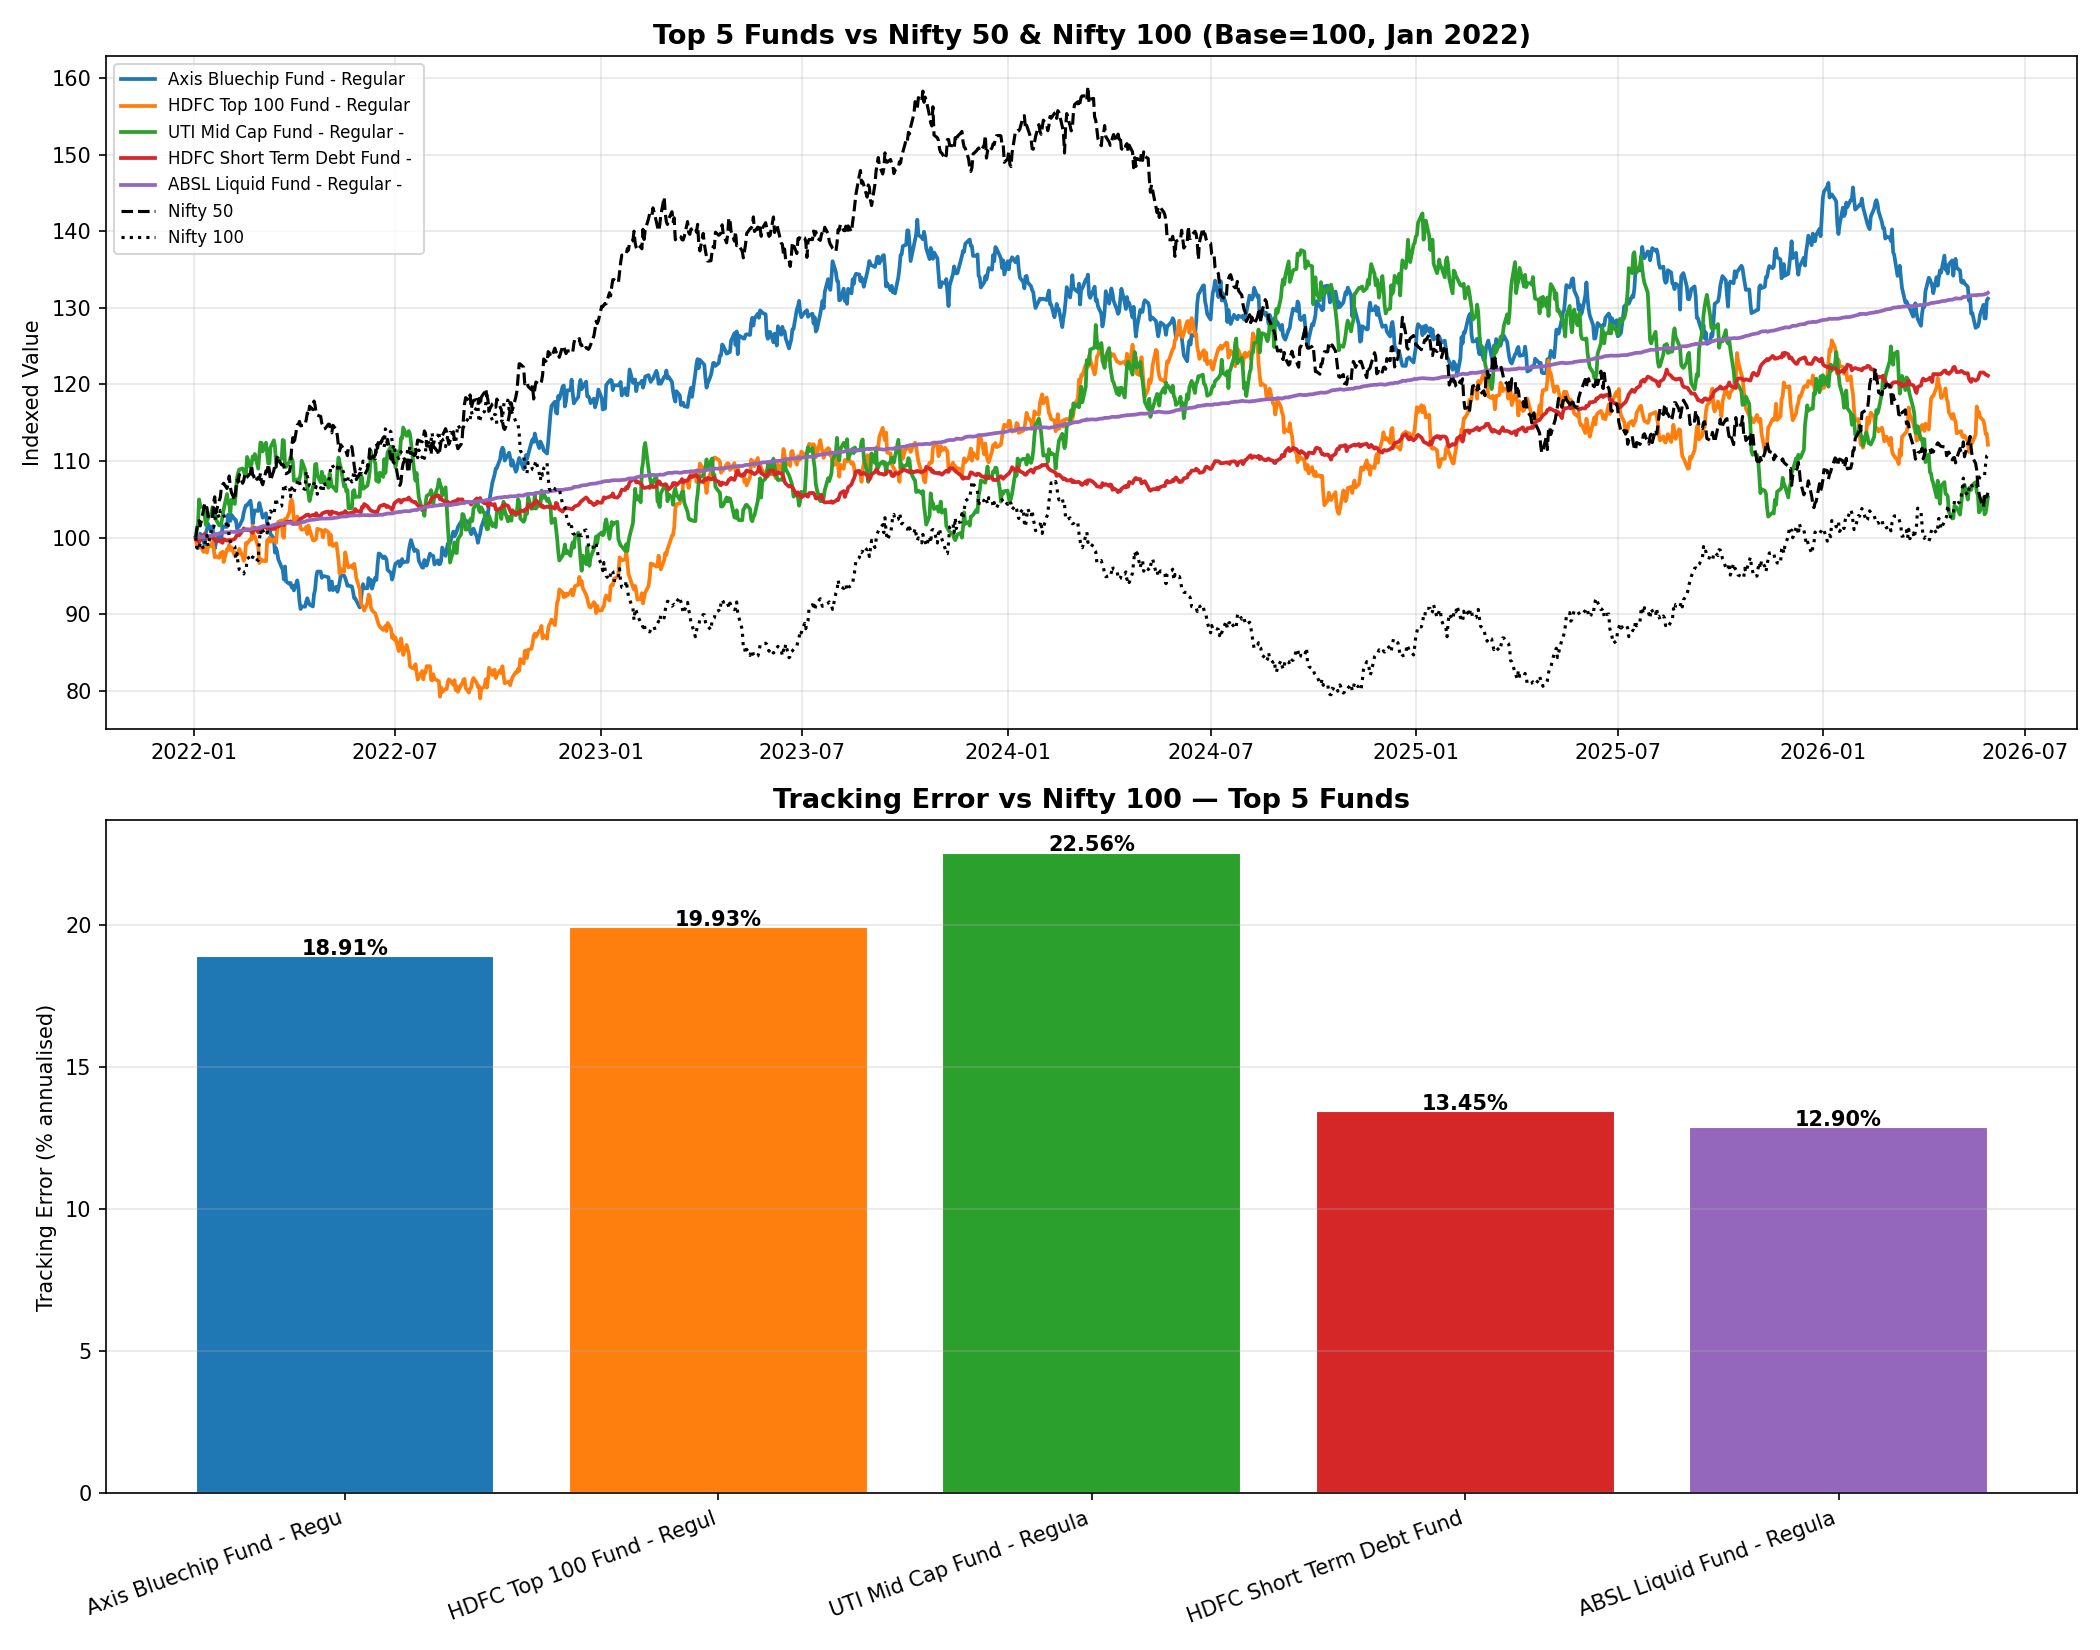

In [10]:

from IPython.display import Image
Image('reports/benchmark_comparison.png')


In [11]:

# Also show tracking error table
top5 = sc.head(5)
te_rows = []
for _, row in top5.iterrows():
    fr = nav[nav['amfi_code']==row['amfi_code']].set_index('date')['daily_return'].dropna()
    common = fr.index.intersection(n100.index)
    if len(common)>10:
        te = (fr.loc[common]-n100.loc[common]).std()*np.sqrt(252)*100
        te_rows.append({'Fund':row['scheme_name'][:35], 'Tracking Error (%)':round(te,2),
                        'Alpha':row['alpha'], 'Beta':row['beta']})
print(pd.DataFrame(te_rows).to_string(index=False))


                               Fund  Tracking Error (%)  Alpha    Beta
Axis Bluechip Fund - Regular - Grow               18.91 0.0690  0.0097
HDFC Top 100 Fund - Regular Plan -                19.93 0.0375 -0.0583
UTI Mid Cap Fund - Regular - Growth               22.56 0.0290 -0.0421
HDFC Short Term Debt Fund - Regular               13.45 0.0428  0.0012
ABSL Liquid Fund - Regular - Growth               12.90 0.0609  0.0003
